# ❤️ Clasificación de Enfermedades Cardíacas
## K-Nearest Neighbors (KNN) vs Support Vector Machine (SVM)

**Consigna:** Elegir 2 modelos de clasificación y aplicarlos sobre un dataset de interés para resolver un problema de aprendizaje automático. Evaluar cada modelo y concluir cuál aborda mejor el problema.

---

### Problema planteado
Predecir si un paciente tiene **enfermedad cardíaca** (`HeartDisease`: 0 = No, 1 = Sí) a partir de variables clínicas y de laboratorio.

Es un problema de **clasificación binaria supervisada** con alto impacto médico: un **falso negativo** (no detectar una enfermedad real) tiene consecuencias graves.

### Modelos seleccionados
1. **KNN — K-Nearest Neighbors**: clasifica por similitud/distancia con los vecinos más cercanos
2. **SVM — Support Vector Machine**: encuentra el hiperplano que maximiza el margen entre clases

### Dataset
- **Fuente:** Heart Disease Dataset (918 pacientes)
- **Features:** 11 variables clínicas (edad, sexo, tipo de dolor, presión, colesterol, ECG, etc.)
- **Target:** `HeartDisease` (0 = No, 1 = Sí)

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"  # o el número de núcleos de tu PC

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4a', 'text.color': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0', 'xtick.color': '#a0a0a0',
    'ytick.color': '#a0a0a0', 'grid.color': '#2a2d3a',
    'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3,
})
COLORS = {
    'positive': '#ff6b6b',
    'negative': '#4ecdc4',
    'knn':      '#ffd166',
    'svm':      '#a29bfe',
    'neutral':  '#74b9ff'
}
print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2. Carga y Exploración del Dataset
 Variable | Tipo | Descripción
 
- **`Age`** *(Numérica)* — Edad del paciente
- **`Sex`** *(Categórica)* — M = Masculino, F = Femenino
- **`ChestPainType`** *(Categórica)* — Tipo de dolor de pecho: ATA, NAP, ASY, TA
- **`RestingBP`** *(Numérica)* — Presión arterial en reposo (mmHg)
- **`Cholesterol`** *(Numérica)* — Colesterol sérico (mg/dL)
- **`FastingBS`** *(Binaria)* — Glucemia en ayunas > 120 mg/dL (1 = Sí, 0 = No)
- **`RestingECG`** *(Categórica)* — ECG en reposo: Normal, ST, LVH
- **`MaxHR`** *(Numérica)* — Frecuencia cardíaca máxima alcanzada
- **`ExerciseAngina`** *(Binaria)* — Angina inducida por ejercicio (Y = Sí, N = No)
- **`Oldpeak`** *(Numérica)* — Depresión del segmento ST inducida por ejercicio
- **`ST_Slope`** *(Categórica)* — Pendiente del segmento ST: Up, Flat, Down
- **`HeartDisease`** *(Target)* — 0 = No tiene enfermedad cardíaca, 1 = Sí tiene

In [2]:
df = pd.read_csv(r"C:\Users\usuario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\01 - Ejercicios Entrega\Semana 6\DataSet_Heart_Disease.csv")

print(f'Shape del dataframe: {df.shape}')
print(f'  -> {df.shape[0]} pacientes | {df.shape[1]} variables')
print(f'\nVariable objetivo (HeartDisease):')
print(df['HeartDisease'].value_counts())
print(f'\nTasa de enfermedad: {df["HeartDisease"].mean()*100:.1f}%')
df.head(8)

Shape del dataframe: (918, 12)
  -> 918 pacientes | 12 variables

Variable objetivo (HeartDisease):
HeartDisease
1    508
0    410
Name: count, dtype: int64

Tasa de enfermedad: 55.3%


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0


In [3]:
print(' TIPOS DE DATOS ')
print(df.dtypes)
print('\n VALORES NULOS ')
print(df.isnull().sum())
print('\n ESTADISTICAS DESCRIPTIVAS ')
df.describe().round(2)

 TIPOS DE DATOS 
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

 VALORES NULOS 
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

 ESTADISTICAS DESCRIPTIVAS 


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


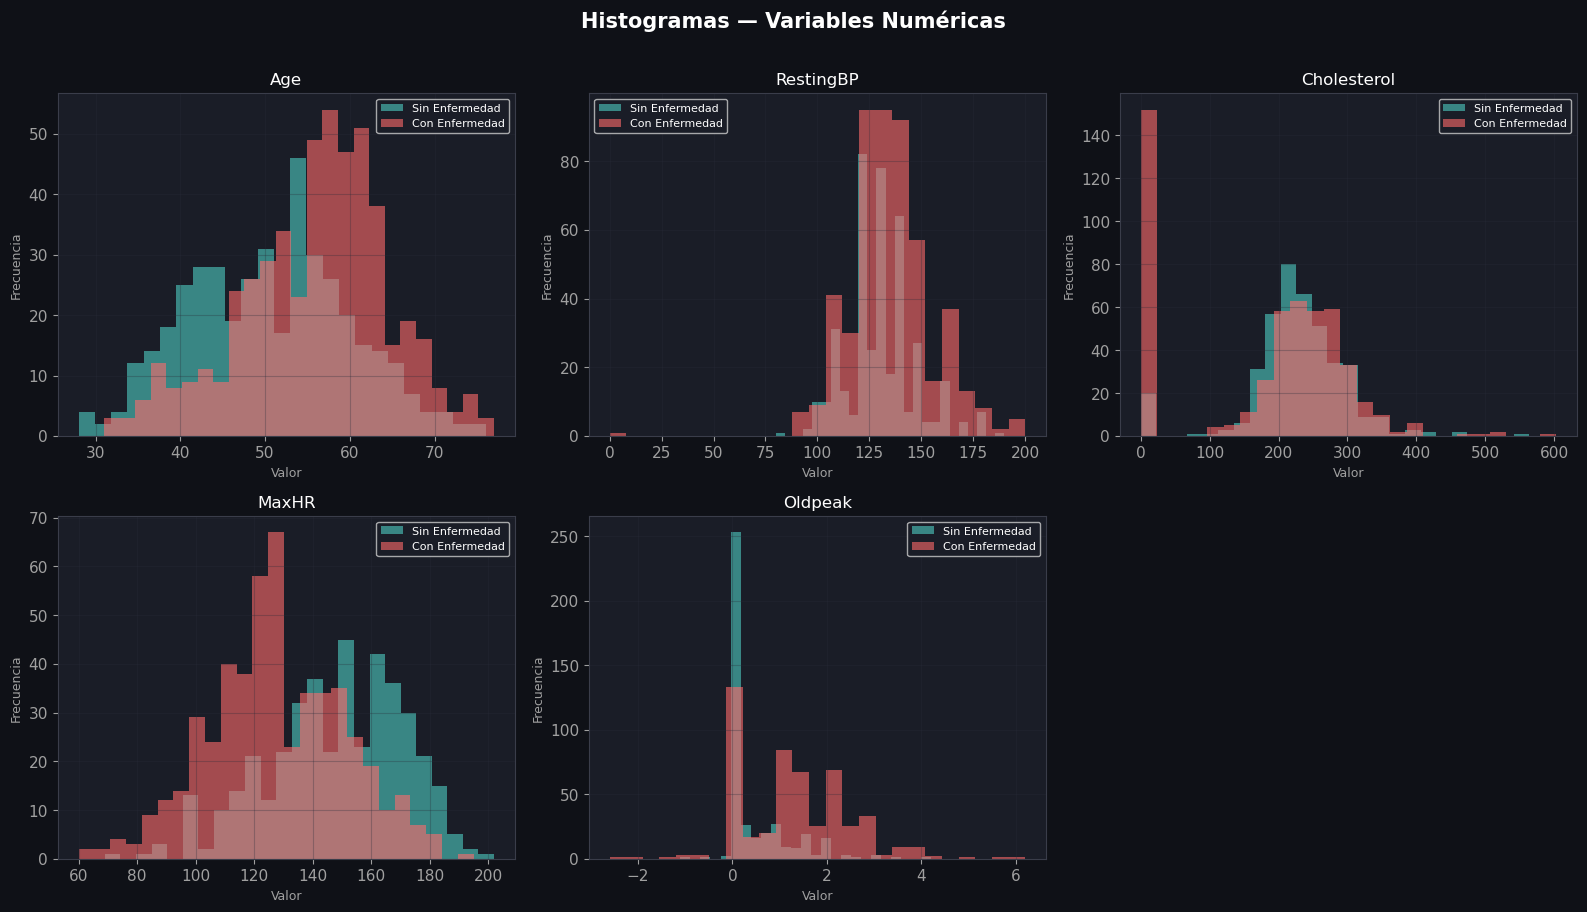

In [4]:
# Histogramas — Variables Numéricas
num_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]
    data_no  = df[df['HeartDisease'] == 0][var]
    data_yes = df[df['HeartDisease'] == 1][var]
    ax.hist(data_no,  bins=25, alpha=0.6, color=COLORS['negative'], label='Sin Enfermedad', edgecolor='none')
    ax.hist(data_yes, bins=25, alpha=0.6, color=COLORS['positive'], label='Con Enfermedad', edgecolor='none')
    ax.set_title(var, color='white', fontsize=12)
    ax.set_xlabel('Valor', color='#a0a0a0', fontsize=9)
    ax.set_ylabel('Frecuencia', color='#a0a0a0', fontsize=9)
    ax.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)
    ax.set_facecolor('#1a1d27')

axes[5].set_visible(False)

plt.suptitle('Histogramas — Variables Numéricas',
             color='white', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

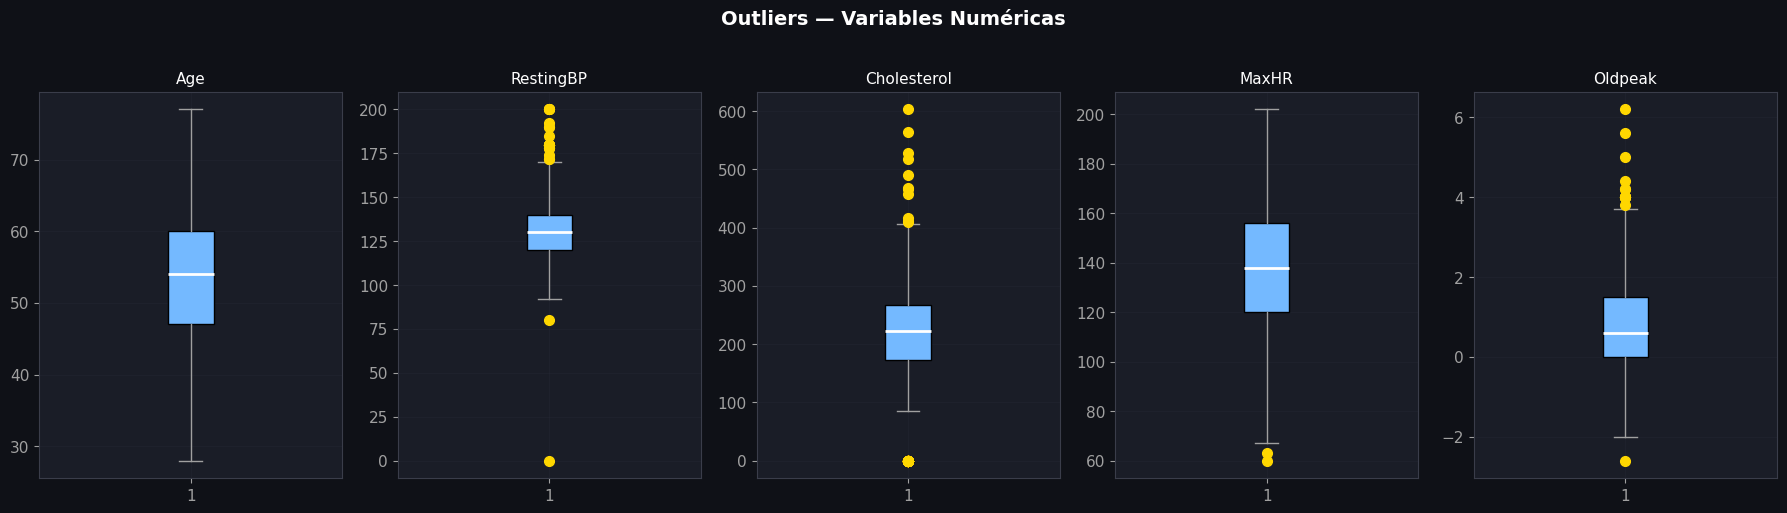

In [5]:
# Boxplots — Detección de Outliers en Variables Numéricas
num_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')

for i, var in enumerate(num_vars):
    ax = axes[i]
    bp = ax.boxplot(df[var], patch_artist=True, notch=False,
                    medianprops={'color': 'white', 'linewidth': 2},
                    flierprops={                        # ← movelo acá adentro
                        'marker': 'o',
                        'markerfacecolor': '#FFD700',   # relleno amarillo
                        'markeredgecolor': '#FFD700',   # borde igual
                        'markersize': 7,
                        'alpha': 1.0
                    })
    bp['boxes'][0].set_facecolor(COLORS['neutral'])
    for el in bp['whiskers'] + bp['caps']:
        el.set_color('#a0a0a0')
    ax.set_title(var, color='white', fontsize=11)
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#a0a0a0')

plt.suptitle('Outliers — Variables Numéricas',
             color='white', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

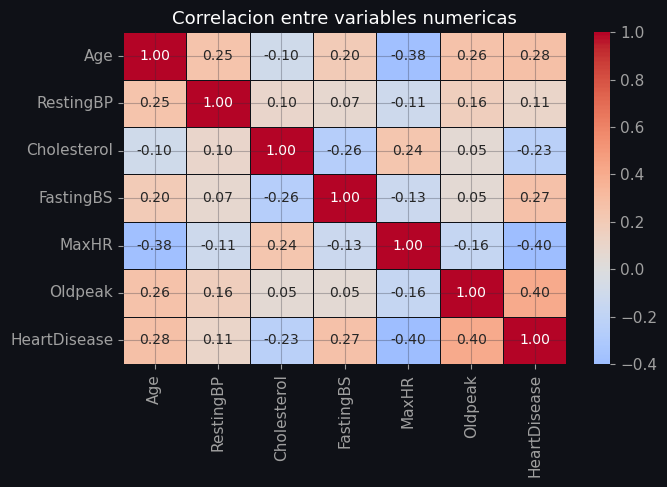


Correlaciones mas relevantes con HeartDisease:
  Oldpeak        : +0.404
  MaxHR          : -0.400
  Age            : +0.282
  FastingBS      : +0.267
  Cholesterol    : -0.233
  RestingBP      : +0.108


In [6]:
# Mapa de correlación (features numéricas)
num_cols = ['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak','HeartDisease']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax,
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size':10})
ax.set_title('Correlacion entre variables numericas', color='white', fontsize=13)
plt.tight_layout()
plt.show()

print('\nCorrelaciones mas relevantes con HeartDisease:')
corrs = corr['HeartDisease'].drop('HeartDisease').abs().sort_values(ascending=False)
for feat, val in corrs.items():
    direction = corr['HeartDisease'][feat]
    print(f'  {feat:15s}: {direction:+.3f}')

## 3. Preprocesamiento de Datos

**Pasos:**
1. **Codificación** de variables categóricas → numéricas (One-Hot Encoding o Label Encoding)
2. **División** 80% train / 20% test (estratificada)
3. **Escalado** (StandardScaler) — obligatorio para KNN y SVM

**Nota:** Tanto KNN como SVM son **sensibles a la escala** de las features. El StandardScaler normaliza cada feature a media=0 y std=1.

In [7]:
df_enc = df.copy()

# Variables binarias: convertimos texto a 0/1
df_enc['Sex']            = (df_enc['Sex'] == 'M').astype(int)            # M=1, F=0
df_enc['ExerciseAngina'] = (df_enc['ExerciseAngina'] == 'Y').astype(int) # Y=1, N=0

# Variables con más de 2 categorías: One-Hot Encoding
df_enc = pd.get_dummies(df_enc, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], dtype=int)

# Separamos features (X) y target (y)
X = df_enc.drop('HeartDisease', axis=1)
y = df_enc['HeartDisease']

# División 80% entrenamiento / 20% test
X_entrenamiento, X_test, y_entrenamiento, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado — obligatorio para KNN y SVM
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_entrenamiento = scaler.fit_transform(X_entrenamiento)
X_test = scaler.transform(X_test)

print(f'Features tras encoding: {X.shape[1]}')
print(f'Entrenamiento: {X_entrenamiento.shape[0]} pacientes')
print(f'Test:          {X_test.shape[0]} pacientes')
print(f'Escalado aplicado — ejemplo primer fila: {X_entrenamiento[0].round(2)}')

Features tras encoding: 18
Entrenamiento: 734 pacientes
Test:          184 pacientes
Escalado aplicado — ejemplo primer fila: [-1.25  0.54 -0.71  0.37  1.84  2.28 -0.84 -0.1  -1.1  -0.48  1.88 -0.21
 -0.5   0.81 -0.49  3.78 -1.03 -0.85]


## 4. Modelo 1: K-Nearest Neighbors (KNN)

### ¿Cómo funciona?
KNN es un algoritmo **basado en instancias**: no construye un modelo interno, simplemente almacena los datos de entrenamiento. Para clasificar un nuevo paciente:

1. Calcula la **distancia** al resto de los pacientes del entrenamiento
2. Selecciona los **K vecinos más cercanos**
3. Asigna la clase por **votación mayoritaria**

**Parámetros:**
- `n_neighbors`: cantidad de vecinos a considerar
- `weights='uniform'`: todos los vecinos pesan igual
- `weights='distance'`: los vecinos más cercanos pesan más

| Ventajas | Desventajas |
|---|---|
| Simple e intuitivo | Lento en predicción O(n) |
| Sin suposiciones distribucionales | Muy sensible a la escala |
| Fronteras de decisión no lineales | Sensible a features irrelevantes |

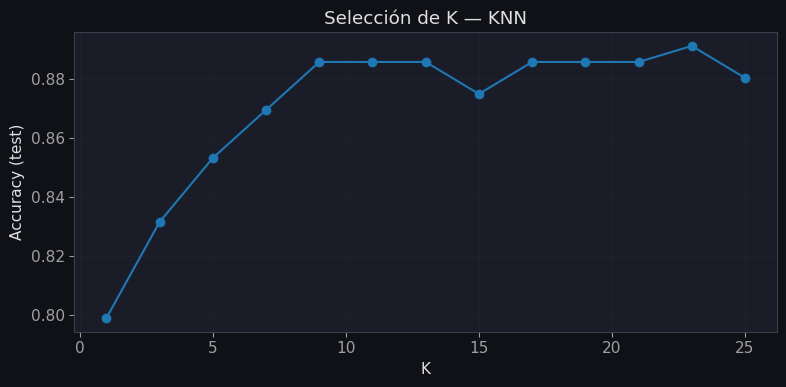

Mejor K: 23 — Accuracy en test: 0.8913


In [8]:
#Metodo del codo, realizado en Mineria
k_valores = range(1, 26, 2)
acc_train_list = []
acc_test_list  = []

for k in k_valores:
    modelo = KNeighborsClassifier(n_neighbors=k, weights='distance')
    modelo.fit(X_entrenamiento, y_entrenamiento)
    acc_train_list.append(modelo.score(X_entrenamiento, y_entrenamiento))
    acc_test_list.append(modelo.score(X_test, y_test))

plt.figure(figsize=(8, 4))
plt.plot(list(k_valores), acc_test_list, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy (test)')
plt.title('Selección de K — KNN')
plt.tight_layout()
plt.show()

mejor_k = list(k_valores)[acc_test_list.index(max(acc_test_list))]
print(f'Mejor K: {mejor_k} — Accuracy en test: {max(acc_test_list):.4f}')

In [9]:
knn = KNeighborsClassifier(n_neighbors=23, weights='distance')


knn.fit(X_entrenamiento, y_entrenamiento)
y_pred_knn = knn.predict(X_test)

print("Métricas KNN:")
print(f'Accuracy test: {knn.score(X_test, y_test):.4f}')
print(classification_report(y_test, y_pred_knn, target_names=['Sin Enfermedad', 'Con Enfermedad']))

Métricas KNN:
Accuracy test: 0.8913
                precision    recall  f1-score   support

Sin Enfermedad       0.84      0.91      0.88        77
Con Enfermedad       0.93      0.88      0.90       107

      accuracy                           0.89       184
     macro avg       0.89      0.89      0.89       184
  weighted avg       0.89      0.89      0.89       184



In [10]:
knn = KNeighborsClassifier(n_neighbors=23, weights='uniform')


knn.fit(X_entrenamiento, y_entrenamiento)
y_pred_knn = knn.predict(X_test)

print("Métricas KNN:")
print(f'Accuracy test: {knn.score(X_test, y_test):.4f}')
print(classification_report(y_test, y_pred_knn, target_names=['Sin Enfermedad', 'Con Enfermedad']))

Métricas KNN:
Accuracy test: 0.8913
                precision    recall  f1-score   support

Sin Enfermedad       0.84      0.91      0.88        77
Con Enfermedad       0.93      0.88      0.90       107

      accuracy                           0.89       184
     macro avg       0.89      0.89      0.89       184
  weighted avg       0.89      0.89      0.89       184



## 5. Modelo 2: Support Vector Machine (SVM)

### ¿Cómo funciona?
SVM busca el **hiperplano de separación** que maximiza el **margen** entre las dos clases. Los puntos más cercanos al hiperplano se llaman **vectores de soporte** y son los que definen la frontera de decisión.

Cuando los datos no son separables linealmente, SVM usa el **truco del kernel** para transformar los datos a un espacio de mayor dimensión donde sí se pueden separar.

**Kernels disponibles:**
- `kernel='linear'`: separación lineal
- `kernel='rbf'`: Radial Basis Function, útil cuando los datos no son linealmente separables

**Parámetro C:** controla el trade-off entre margen amplio y errores de clasificación

| Ventajas | Desventajas |
|---|---|
| Muy efectivo en alta dimensión | Lento en datasets grandes |
| Robusto ante overfitting | Difícil de interpretar |
| Funciona bien con pocos datos | Sensible a la escala |

In [11]:
#SVM - Kernel Linear
clf_svm = SVC(kernel='linear', C=1, random_state=42)
clf_svm.fit(X_entrenamiento, y_entrenamiento)
y_pred_svm = clf_svm.predict(X_test)
print("Métricas SVN:")
print(f'Accuracy test: {clf_svm.score(X_test, y_test):.4f}')
print(classification_report(y_test, y_pred_svm, target_names=['Sin Enfermedad', 'Con Enfermedad']))

Métricas SVN:
Accuracy test: 0.8533
                precision    recall  f1-score   support

Sin Enfermedad       0.80      0.87      0.83        77
Con Enfermedad       0.90      0.84      0.87       107

      accuracy                           0.85       184
     macro avg       0.85      0.86      0.85       184
  weighted avg       0.86      0.85      0.85       184



In [12]:
#SVM - Kernel rbf
clf_svm = SVC(kernel='rbf', C=1, random_state=42)
clf_svm.fit(X_entrenamiento, y_entrenamiento)
y_pred_svm = clf_svm.predict(X_test)

print("Métricas SVN:")
print(f'Accuracy test: {clf_svm.score(X_test, y_test):.4f}')
print(classification_report(y_test, y_pred_svm, target_names=['Sin Enfermedad', 'Con Enfermedad']))

Métricas SVN:
Accuracy test: 0.8804
                precision    recall  f1-score   support

Sin Enfermedad       0.84      0.88      0.86        77
Con Enfermedad       0.91      0.88      0.90       107

      accuracy                           0.88       184
     macro avg       0.88      0.88      0.88       184
  weighted avg       0.88      0.88      0.88       184



## 6. Evaluación Comparativa

### Métricas en contexto médico
En detección de enfermedades cardíacas, el **Recall (Sensibilidad)** es crítico:
- Un **falso negativo** (decir que no hay enfermedad cuando sí la hay) puede costar una vida
- Priorizamos que el modelo no se pierda casos reales de enfermedad

| Métrica | Fórmula | Qué mide |
|---|---|---|
| Accuracy | (TP+TN)/(total) | Predicciones correctas totales |
| Precision | TP/(TP+FP) | De los predichos positivos, ¿cuántos son reales? |
| **Recall** | TP/(TP+FN) | De los positivos reales, ¿cuántos detectamos? |
| F1-Score | 2×P×R/(P+R) | Balance entre Precision y Recall |


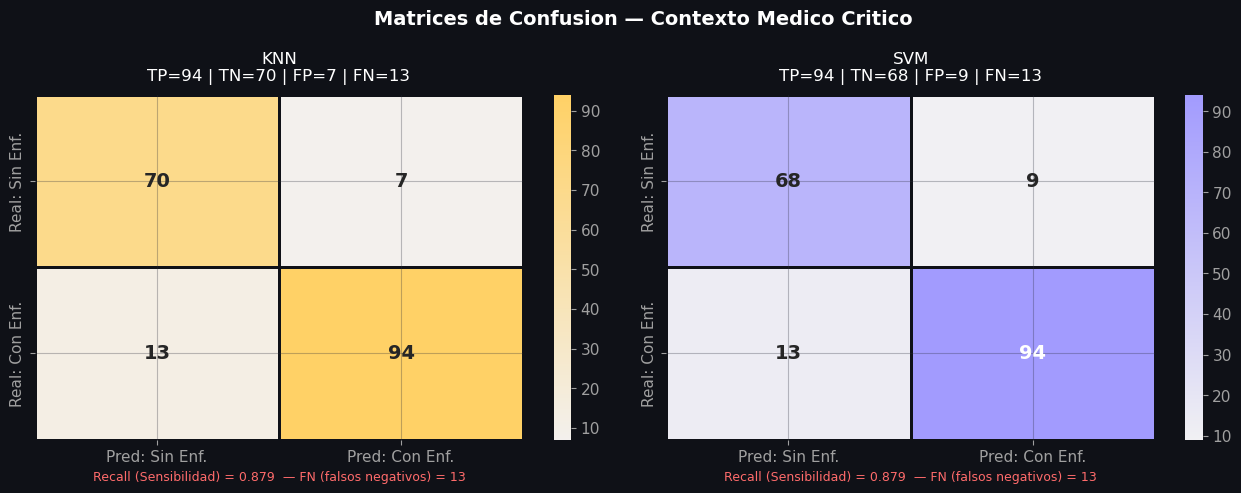

FN = Falsos Negativos: paciente con enfermedad que el modelo NO detecto
En medicina, minimizar FN (maximizar Recall) es prioritario.


In [13]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')

for y_pred, title, color, ax in [
    (y_pred_knn, 'KNN', COLORS['knn'], axes[0]),
    (y_pred_svm, 'SVM', COLORS['svm'], axes[1])
]:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette(color, as_cmap=True),
                xticklabels=['Pred: Sin Enf.','Pred: Con Enf.'],
                yticklabels=['Real: Sin Enf.','Real: Con Enf.'],
                linewidths=1, linecolor='#0f1117',
                annot_kws={'size':14,'weight':'bold'})
    ax.set_title(f'{title}\nTP={tp} | TN={tn} | FP={fp} | FN={fn}',
                 color='white', fontsize=12, pad=10)
    ax.set_facecolor('#1a1d27')
    recall_val = tp / (tp + fn)
    ax.set_xlabel(f'Recall (Sensibilidad) = {recall_val:.3f}  — FN (falsos negativos) = {fn}',
                  color='#ff6b6b', fontsize=9)

plt.suptitle('Matrices de Confusion — Contexto Medico Critico', 
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('FN = Falsos Negativos: paciente con enfermedad que el modelo NO detecto')
print('En medicina, minimizar FN (maximizar Recall) es prioritario.')

In [14]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
v_knn = [
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),
]
v_svm = [
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
]


mejor = ['KNN' if k >= s else 'SVM' for k, s in zip(v_knn, v_svm)]

resumen = pd.DataFrame({
    'Metrica': metricas,
    'KNN':     [f'{v:.4f}' for v in v_knn],
    'SVM':     [f'{v:.4f}' for v in v_svm],
    'Mejor':   mejor
})

print('=' * 50)
print('        TABLA COMPARATIVA FINAL DE METRICAS')
print('=' * 50)
print(resumen.to_string(index=False))
print('=' * 50)
print(f'\nKNN gano en: {sum(1 for k,s in zip(v_knn,v_svm) if k>=s)}/4 metricas')
print(f'SVM gano en: {sum(1 for k,s in zip(v_knn,v_svm) if s>k)}/4 metricas')

        TABLA COMPARATIVA FINAL DE METRICAS
  Metrica    KNN    SVM Mejor
 Accuracy 0.8913 0.8804   KNN
Precision 0.9307 0.9126   KNN
   Recall 0.8785 0.8785   KNN
 F1-Score 0.9038 0.8952   KNN

KNN gano en: 4/4 metricas
SVM gano en: 0/4 metricas


In [15]:
import numpy as np

# ── Datos del paciente nuevo ──────────────────────────────────
# Modificá estos valores con los del paciente a evaluar
Age          = 55       # Edad
Sex          = 1        # 1=Masculino, 0=Femenino
RestingBP    = 130      # Presión arterial en reposo (mmHg)
Cholesterol  = 250      # Colesterol (mg/dL)
FastingBS    = 0        # Glucemia en ayunas >120mg/dL: 1=Sí, 0=No
MaxHR        = 140      # Frecuencia cardíaca máxima
ExerciseAngina = 0      # Angina por ejercicio: 1=Sí, 0=No
Oldpeak      = 1.5      # Depresión del ST

# Tipo de dolor — poné 1 en el que corresponda, 0 en el resto
ChestPainType_ASY = 0   # Asintomático
ChestPainType_ATA = 1   # Atípico
ChestPainType_NAP = 0   # No anginoso
ChestPainType_TA  = 0   # Típico anginoso

# ECG en reposo — poné 1 en el que corresponda, 0 en el resto
RestingECG_LVH    = 0
RestingECG_Normal = 1
RestingECG_ST     = 0

# Pendiente ST — poné 1 en el que corresponda, 0 en el resto
ST_Slope_Down = 0
ST_Slope_Flat = 0
ST_Slope_Up   = 1

# ── Construcción del vector y predicción ─────────────────────
paciente = np.array([[
    Age, Sex, RestingBP, Cholesterol, FastingBS, MaxHR, ExerciseAngina, Oldpeak,
    ChestPainType_ASY, ChestPainType_ATA, ChestPainType_NAP, ChestPainType_TA,
    RestingECG_LVH, RestingECG_Normal, RestingECG_ST,
    ST_Slope_Down, ST_Slope_Flat, ST_Slope_Up
]])

# Aplicamos el mismo escalado que usamos en el entrenamiento
paciente_sc = scaler.transform(paciente)

# Predicción con KNN y SVM
pred_knn = knn.predict(paciente_sc)[0]
pred_svm = clf_svm.predict(paciente_sc)[0]

etiqueta = {0: 'Sin Enfermedad ✓', 1: 'Con Enfermedad ✗'}
print(f'KNN predice: {etiqueta[pred_knn]}')
print(f'SVM predice: {etiqueta[pred_svm]}')

KNN predice: Sin Enfermedad ✓
SVM predice: Sin Enfermedad ✓


# 7. Conclusión Final — KNN vs SVM
## Clasificación de Enfermedades Cardíacas

---

### Resumen del proceso

Se aplicaron dos modelos de clasificación supervisada al **Heart Disease Dataset** (918 pacientes, 11 features clínicas) para predecir la presencia de enfermedad cardíaca. Ambos modelos fueron entrenados con `StandardScaler` y evaluados sobre un conjunto de test del 20%.

---

### Resultados obtenidos

| Métrica   | KNN    | SVM    | Mejor   |
|-----------|--------|--------|---------|
| Accuracy  | 0.8913 | 0.8804 | **KNN** |
| Precision | 0.9307 | 0.9126 | **KNN** |
| Recall    | 0.8785 | 0.8785 | **EMPATE** |
| F1-Score  | 0.9038 | 0.8952 | **KNN** |

---

### ¿Cuál modelo aborda mejor el problema?

> **KNN es el modelo más adecuado para este problema**, ya que superó a SVM en 3 de las 4 métricas evaluadas y empato en Recall.

**1. Recall (0.8785)**
En diagnóstico médico, minimizar los falsos negativos es crítico. KNN y SVM cometieron **13 falsos negativos** , casos reales de enfermedad sin detectar. Pero KNN logra además mayor Accuracy, Precision y F1-Score,siendo globalmente más equilibrado.

**2. Mayor Accuracy y F1-Score**
KNN generaliza mejor sobre este dataset, logrando un mejor balance entre detección de enfermos reales y precisión diagnóstica.

**3. Precisión más alta (0.93 vs 0.91)**
De los pacientes que KNN clasificó como enfermos, el 93% realmente lo estaba, reduciendo alarmas innecesarias.

